# Normalization Layers: Full Comparison and Deep Intuitions

This notebook pulls together everything from the previous three and builds
a unified mental model. We answer:

1. When does each normalization layer fail?
2. What do gradients look like with and without normalization in a deep network?
3. Is normalization a substitute for good initialization?
4. What happens when you stack normalization with residual connections?


In [1]:
import sys; sys.path.insert(0, '../src')
import torch, torch.nn as nn
import numpy as np, matplotlib.pyplot as plt
%matplotlib inline

from norms import BatchNorm1dManual, LayerNormManual, RMSNormManual
from visualize import (plot_training_curves, plot_gradient_flow,
                       plot_activation_distributions, plot_normalization_geometry)
from train import make_dataset, compare_norms, NormMLP, train as run_train


## 1. The Geometry of Normalization

Before writing any more code, here's the core intuition diagram:
which cells of the (N, D) input matrix does each norm type "look at"?


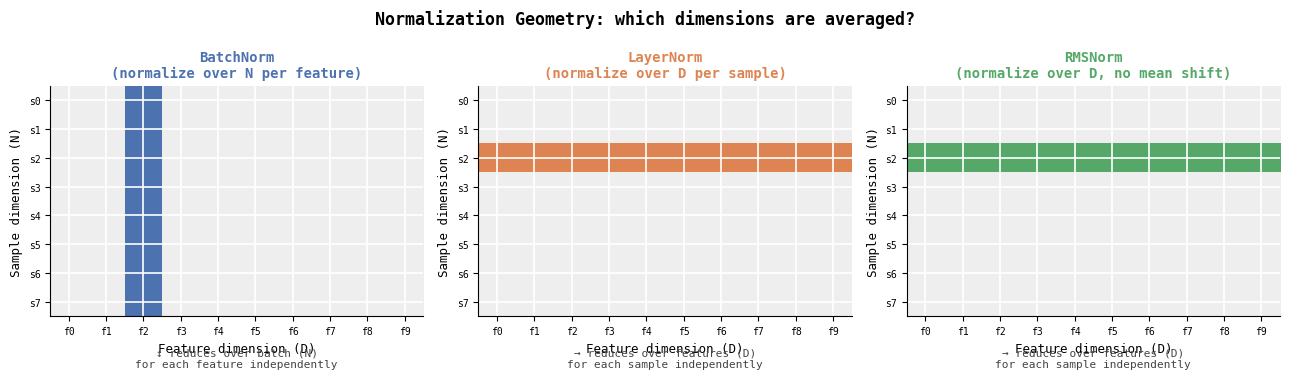

In [2]:
fig = plot_normalization_geometry(n_samples=8, n_features=10)
plt.show()


## 2. Gradient Flow with Deep Networks

One of the most important empirical effects of normalization is stabilizing
gradient magnitudes across layers. Without normalization in a deep network,
gradients tend to either explode or vanish by the time they reach early layers.

Let's measure this directly.


In [3]:
X, Y = make_dataset(n_samples=3000, n_features=32, n_classes=4,
                    covariate_shift=True, seed=7)

norm_factories = {
    'batchnorm': lambda d: nn.BatchNorm1d(d),
    'layernorm': lambda d: nn.LayerNorm(d),
    'rmsnorm':   lambda d: RMSNormManual(d),
    'nonorm':    None,
}

all_histories = compare_norms(
    norm_factories, X, Y,
    hidden_dim=128, n_layers=6,
    lr=0.02, n_steps=1000, batch_size=64
)



  Training with: batchnorm
step     0 | loss 1.4165
step   100 | loss 0.3619
step   200 | loss 0.1847
step   300 | loss 0.3800
step   400 | loss 0.1777
step   500 | loss 0.1387
step   600 | loss 0.1633
step   700 | loss 0.1106
step   800 | loss 0.1989
step   900 | loss 0.2665

  Training with: layernorm
step     0 | loss 1.4492
step   100 | loss 0.2243
step   200 | loss 0.1505
step   300 | loss 0.1406
step   400 | loss 0.0675
step   500 | loss 0.0772
step   600 | loss 0.0568
step   700 | loss 0.0859
step   800 | loss 0.0810
step   900 | loss 0.0462

  Training with: rmsnorm
step     0 | loss 1.4714
step   100 | loss 0.2253
step   200 | loss 0.1466
step   300 | loss 0.1475
step   400 | loss 0.0681
step   500 | loss 0.0829
step   600 | loss 0.0599
step   700 | loss 0.0945
step   800 | loss 0.0858
step   900 | loss 0.0450

  Training with: nonorm
step     0 | loss 1.4051
step   100 | loss 0.9233
step   200 | loss 0.5162
step   300 | loss 0.2914
step   400 | loss 0.1999
step   500 | loss 

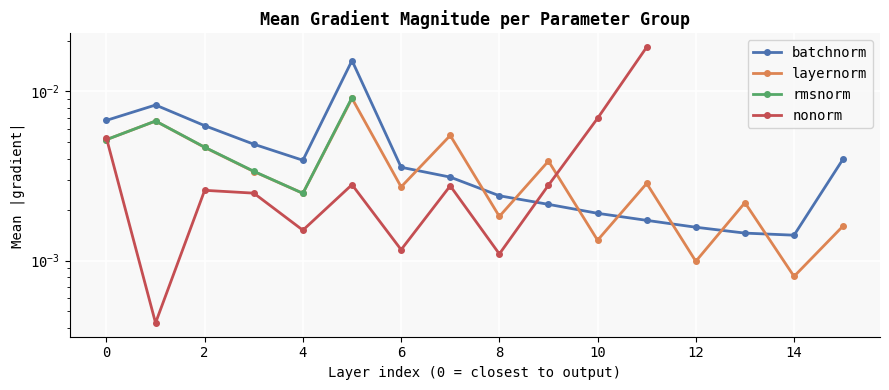

In [4]:
# Extract per-layer gradient norms (averaged over training)
grad_flow = {}
for name, h in all_histories.items():
    if h['grad_norms']:
        arr = np.array(h['grad_norms'])
        grad_flow[name] = arr.mean(axis=0).tolist()

fig = plot_gradient_flow(grad_flow, title="Mean Gradient Magnitude per Parameter Group")
plt.show()


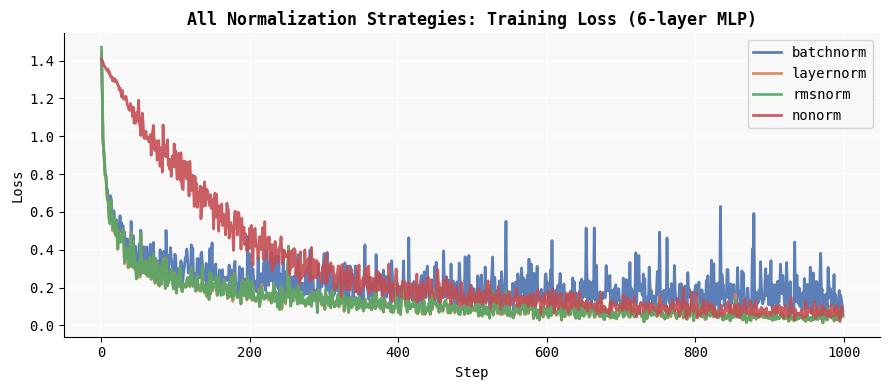

In [5]:
fig = plot_training_curves(
    {k: v['losses'] for k, v in all_histories.items()},
    title="All Normalization Strategies: Training Loss (6-layer MLP)"
)
plt.show()

## 3. Normalization is NOT a Substitute for Good Initialization

A common misconception: "I'm using BatchNorm so I don't need to worry about init."
This is wrong. Normalization helps with stability during training, but a catastrophic
initial state (e.g., very large weights → saturated tanh) will prevent the network
from even starting to learn.

Let's demonstrate: with bad initialization, even BatchNorm fails.


step     0 | loss 1.5023
step     0 | loss 8.2979


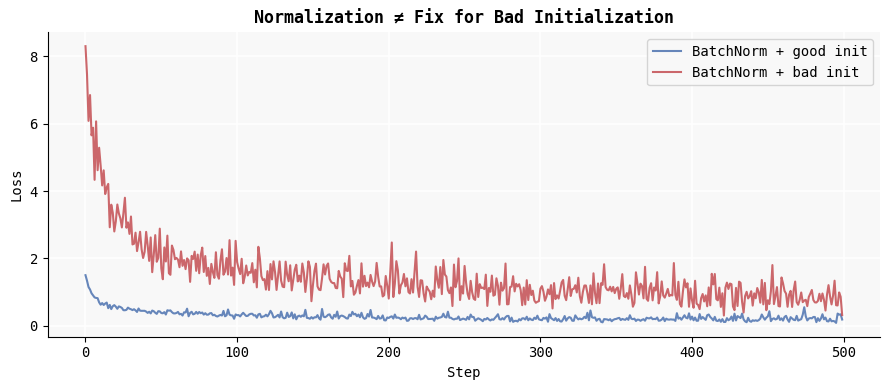

In [6]:
torch.manual_seed(0)
# Bad init: scale all weights up by 10x after creation
def bad_init_model(norm_factory):
    model = NormMLP(32, 128, 4, n_layers=4, norm_factory=norm_factory)
    with torch.no_grad():
        for p in model.parameters():
            p.mul_(10.0)  # catastrophically large
    return model

good_bn = NormMLP(32, 128, 4, n_layers=4, norm_factory=lambda d: nn.BatchNorm1d(d))
bad_bn  = bad_init_model(lambda d: nn.BatchNorm1d(d))

h_good = run_train(good_bn, X, Y, lr=0.02, n_steps=500, batch_size=64, log_every=500)
h_bad  = run_train(bad_bn,  X, Y, lr=0.02, n_steps=500, batch_size=64, log_every=500)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(h_good['losses'], label='BatchNorm + good init', color='#4C72B0', alpha=0.85)
ax.plot(h_bad['losses'],  label='BatchNorm + bad init',  color='#C44E52', alpha=0.85)
ax.set_title("Normalization ≠ Fix for Bad Initialization", fontweight='bold')
ax.set_xlabel("Step"); ax.set_ylabel("Loss"); ax.legend()
plt.tight_layout(); plt.show()


## 4. Pre-Norm vs Post-Norm (Residual Networks)

Modern transformers use **Pre-LayerNorm** (norm before the sublayer)
rather than the original **Post-LayerNorm** (norm after the addition).

```
Post-Norm (original Attention is All You Need):
  x = LayerNorm(x + Sublayer(x))

Pre-Norm (GPT-2, LLaMA, modern default):
  x = x + Sublayer(LayerNorm(x))
```

Pre-Norm gives better gradient flow because the residual path is always
unobstructed — gradients can flow directly back through `x` without
passing through the normalization.


Training Pre-Norm...
Training Post-Norm...


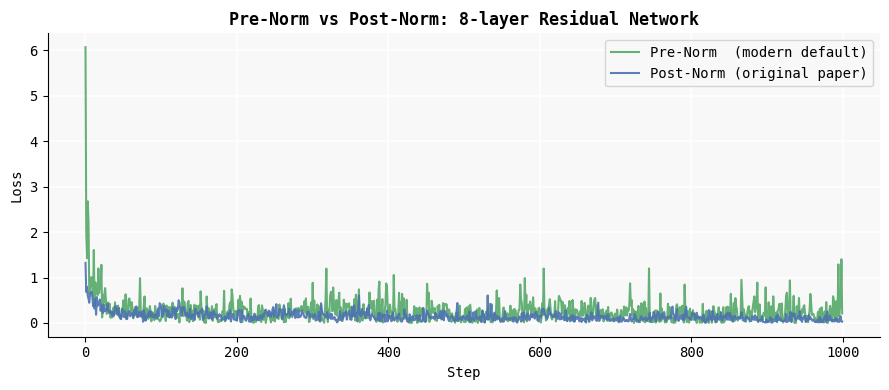

In [7]:
class PostNormBlock(nn.Module):
    def __init__(self, d): 
        super().__init__()
        self.linear = nn.Linear(d, d)
        self.norm   = nn.LayerNorm(d)
    def forward(self, x):
        return self.norm(x + torch.relu(self.linear(x)))

class PreNormBlock(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.linear = nn.Linear(d, d)
        self.norm   = nn.LayerNorm(d)
    def forward(self, x):
        return x + torch.relu(self.linear(self.norm(x)))

class DeepResNet(nn.Module):
    def __init__(self, d, n_blocks, block_cls, in_dim, out_dim):
        super().__init__()
        self.embed  = nn.Linear(in_dim, d)
        self.blocks = nn.Sequential(*[block_cls(d) for _ in range(n_blocks)])
        self.head   = nn.Linear(d, out_dim)
    def forward(self, x):
        return self.head(self.blocks(self.embed(x))), []

d, n_blocks = 64, 8

torch.manual_seed(0)
pre_model  = DeepResNet(d, n_blocks, PreNormBlock,  32, 4)
torch.manual_seed(0)
post_model = DeepResNet(d, n_blocks, PostNormBlock, 32, 4)

from train import train as run_train
import torch.nn.functional as F

def train_resnet(model, X, Y, n_steps=1000, lr=0.01, bs=64):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    for step in range(n_steps):
        idx = torch.randint(0, X.shape[0], (bs,))
        xb, yb = X[idx], Y[idx]
        out, _ = model(xb)
        loss = F.cross_entropy(out, yb)
        opt.zero_grad(); loss.backward(); opt.step()
        losses.append(loss.item())
    return losses

print("Training Pre-Norm...")
pre_losses  = train_resnet(pre_model,  X, Y)
print("Training Post-Norm...")
post_losses = train_resnet(post_model, X, Y)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(pre_losses,  label='Pre-Norm  (modern default)', color='#55A868', alpha=0.9)
ax.plot(post_losses, label='Post-Norm (original paper)', color='#4C72B0', alpha=0.9)
ax.set_title("Pre-Norm vs Post-Norm: 8-layer Residual Network", fontweight='bold')
ax.set_xlabel("Step"); ax.set_ylabel("Loss"); ax.legend()
plt.tight_layout(); plt.show()


## 5. Quick Reference: Choosing a Normalization Layer

```
Task                                  → Norm
─────────────────────────────────────────────
CNN, large batch (≥16), vision        → BatchNorm
Transformer, NLP, seq2seq             → LayerNorm
Modern LLM (LLaMA, Mistral, Gemma)   → RMSNorm
Small batch, 4D feature maps          → GroupNorm
Online learning / batch size = 1      → LayerNorm or RMSNorm
```

## 6. Final Summary Table

| Property | BatchNorm | LayerNorm | RMSNorm |
|---|---|---|---|
| Normalizes over | N (batch) | D (features) | D (features, no mean) |
| Statistics | per-feature | per-sample | per-sample |
| Running stats needed | Yes | No | No |
| Works at batch size 1 | No (eval only) | Yes | Yes |
| Parameters | γ, β | γ, β | γ only |
| Computational cost | 1.0x | ~1.0x | ~0.93x |
| Used in | ResNets, VGG | BERT, GPT-2 | LLaMA, Mistral |
| Year | 2015 | 2016 | 2019 |

The deeper insight: all of these are doing the same thing conceptually —
**making the optimization landscape smoother** by controlling the scale of
activations. The differences are about *which* statistical dependencies they
introduce and *where* they apply in the computation graph.
